# Canonical Model 06: Ensemble Uncertainty & IES Diagnostics

This notebook works through the **per-cycle ensemble diagnostics** to look at every time: prior Monte Carlo and prior-data conflict, phi distribution & contribution, parameters at bounds, posterior forecast uncertainty, and **spatial K-field ("property pattern") maps**.

It calibrates a *spatially-varying* K field (one geostatistical parameter per Voronoi cell), so the maps in section 8 answer the workshop's question: *property patterns -- plausible or laughable?* Every plot offers both a `plotly` and a `matplotlib` backend.

In [1]:
import sys
from pathlib import Path

# Make the in-repo `src/` importable when myflopy is not pip-installed.
src = Path.cwd().parents[2] / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

import pandas as pd
import myflopy as mf
from canonical_notebook_style import notebook_header
from myflopy.modflow.mf6.canonical_calibration import build_canonical_calibration_demo
from myflopy.modflow.mf6.pest import PestProject
from myflopy.modflow.mf6.grid.plotting import build_choropleth

notebook_header('06', 'Ensemble Uncertainty & IES Diagnostics',
                'Prior MC, prior-data conflict, phi & weight diagnostics, forecast uncertainty, K-field maps.')

## 1. Build and declare the PEST problem (grid K)

In [2]:
artifact_root = Path('../artifacts/canonical_pest')
artifact_root.mkdir(parents=True, exist_ok=True)

# A SMOOTH synthetic truth K field (a homogeneous base x a smooth anomaly) on
# the two unconfined layers, with a flat-base START -- IES recovers the spatial
# pattern AND the prior brackets the data. (The model's own sharp paleochannel K
# is a near-extreme low-head configuration a smooth prior cannot bracket, which
# is why we use a smooth synthetic anomaly here.)
demo = build_canonical_calibration_demo(artifact_root / 'model', synthetic_k=True,
                                        synthetic_k_base=20.0, start_k_layers=(0, 1))

# No workspace=: defaults to <model workspace>/pest/canonical_gridk (see
# demo.model.pest_runs in the last cell).
cal = PestProject(model=demo.model, name='canonical_gridk', start_datetime='2024-01-01')
# Grid K: one geostatistically-correlated multiplier per Voronoi cell on each of
# the two unconfined layers. `capture=True` records every realization's resolved
# K field so we can map it. `correlation` is the variogram range (model units):
# the facade draws a *correlated* prior ensemble so realizations are smooth
# fields, not per-cell noise.
cal.parameterize('k', style='grid', layers=[0, 1], correlation=600.0,
                 bounds=(0.05, 20.0), physical=(0.001, 300.0), capture=True)
cal.parameterize('recharge', style='constant', bounds=(0.3, 3.0), physical=(0.0, 1e-2))
cal.observe(demo.head_targets)
cal.forecast(demo.forecast_targets)
pst = cal.build('canonical_gridk.pst', noptmax=0)
print('adjustable parameters:', pst.npar_adj, '| nonzero obs:', pst.nnz_obs)

VoronoiGrid initializing.


Voronoi grid initialized.


getting connectivity properties (iac, ja, cl12, hwva, nja)


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model viz_prt_master...
    writing model name file...
    writing package disv...


...

    Solving:  Stress period:     6    Time step:     1


    Solving:  Stress period:     6    Time step:     2


 
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2026/06/23 10:18:58
 Elapsed run time:  7.003 Seconds
 
 Normal termination of simulation.

Success is:  True


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\pyemu\utils\pst_from.py:1281: PyemuWarning: add_py_function(): _write_head_target_csv already in forward run python functions, not overriding here, original will be maintained


adjustable parameters: 5001 | nonzero obs: 96


## 2. Prior Monte Carlo -- "early and often"

Evaluate the **prior** parameter ensemble once (`cal.prior(...)`, NOPTMAX = -1) before history matching: is the prior wide enough to explain the data, and is any observation *outside* what the prior can produce? Grey "spaghetti" is the prior simulated ensemble; red triangles are the measured values. **What to look for:** measured points inside the grey band.

2026-06-23 10:19:15,935 - MainProcess - INFO - Reserved port 4235 for process 57648


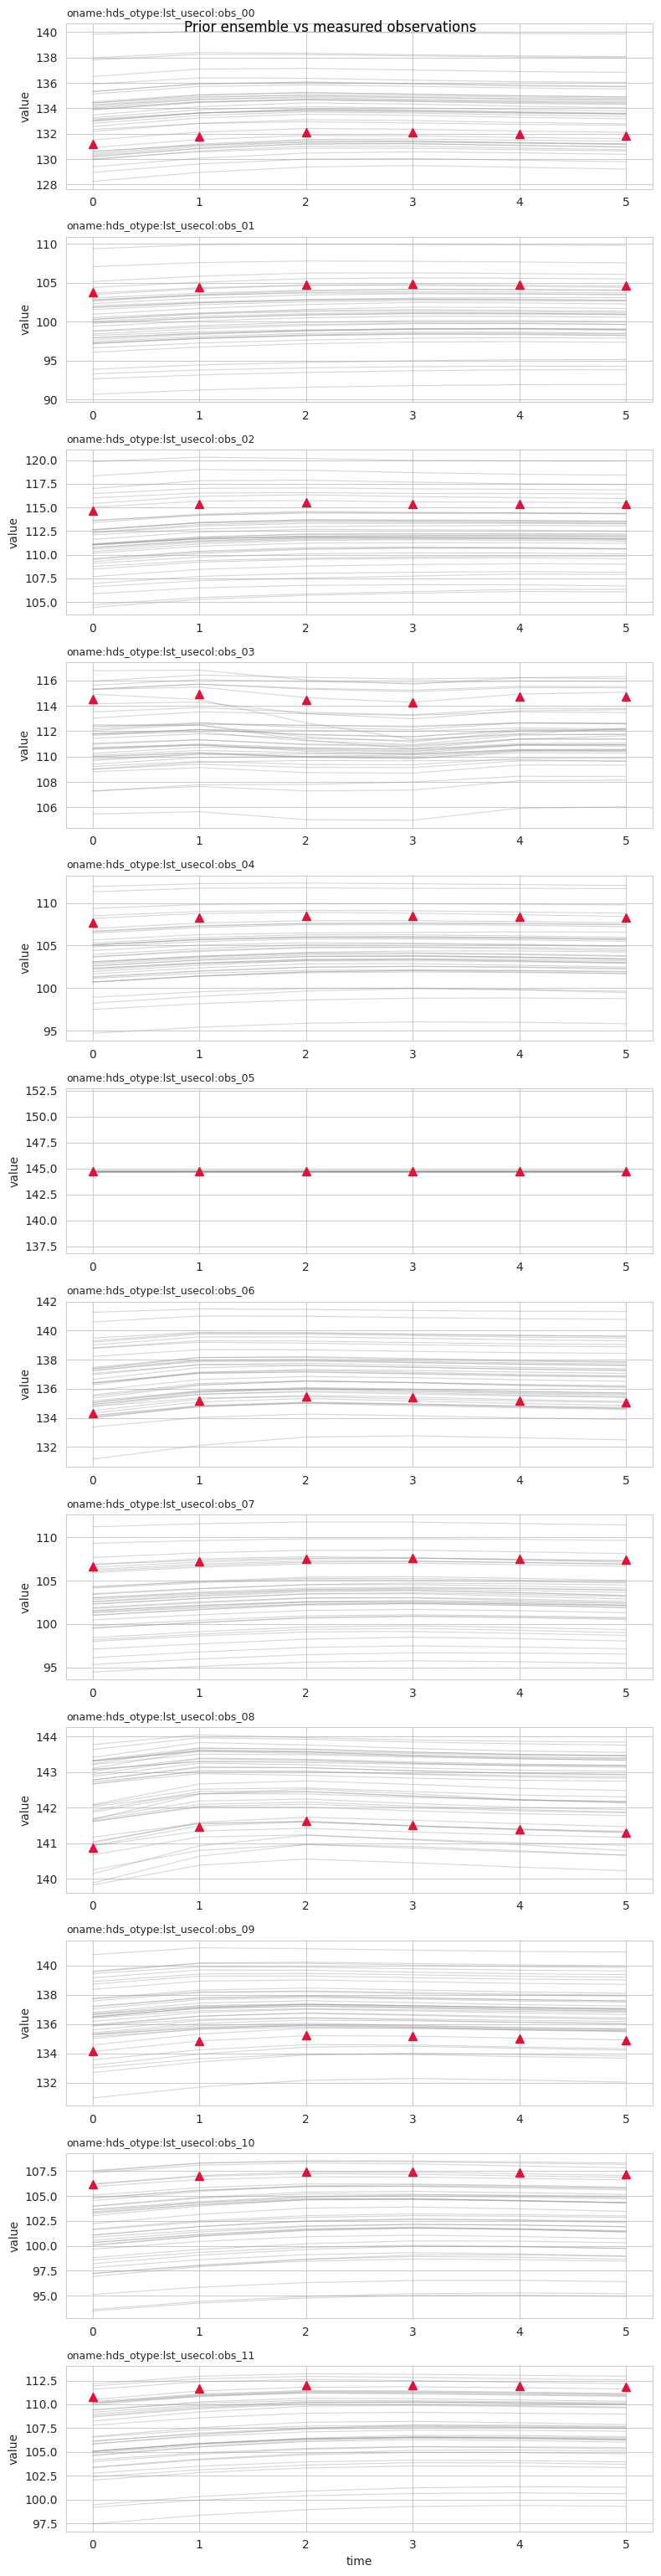

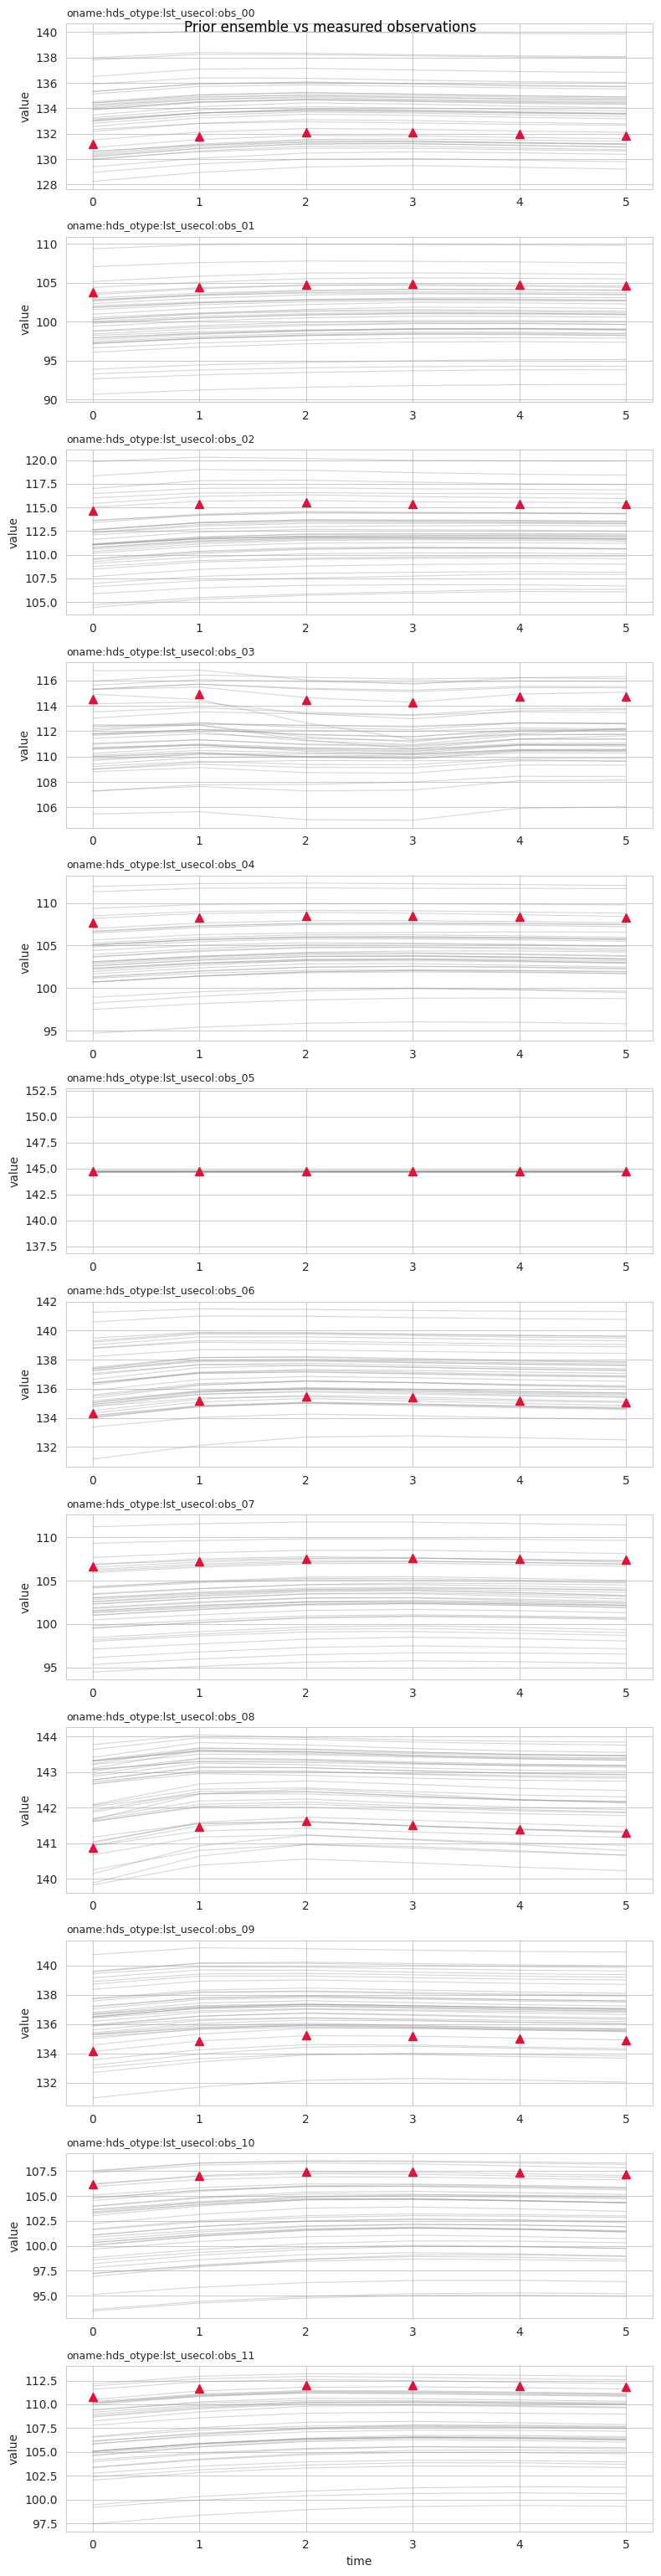

In [3]:
# RUN_IES gates the heavy ensemble work in this notebook (prior MC + IES).
# Saved outputs below are from a completed run. Set RUN_IES = True to
# regenerate them (prior MC ~1-2 min, IES ~6-8 min with 12 workers).
RUN_IES = False
if RUN_IES:
    pm = cal.prior(reals=40, workers=12)
    display(pm.plot_prior_vs_obs())
    display(pm.plot_prior_vs_obs(backend='matplotlib'))
else:
    pm = None


## 3. Prior-data conflict

Where a measured value lies *outside* the prior predictive band, prior and data disagree before calibration starts -- usually a too-narrow prior, a wrong weight, or missing physics. **What to look for:** groups with a high % in conflict; investigate before trusting history matching.

In [4]:
if pm is not None:
    conflict = pm.conflict()
    print('observations in conflict:', int(conflict['in_conflict'].sum()), 'of', len(conflict))
    display(pm.plot_conflict())
    display(conflict[conflict['in_conflict']].head(10))


observations in conflict: 0 of 96


,obgnme,time,measured,prior_lo,prior_hi,prior_mean,in_conflict


## 4. Run PESTPP-IES

A grid-K ensemble (thousands of parameters) with parallel agents -- this is a *go-get-coffee* cell (~minutes). Set `RUN_IES = False` to skip.

In [5]:
if RUN_IES:
    ies = cal.run_ies(reals=30, iterations=3, workers=12)
    print(ies.settings)
else:
    ies = None
    print('Skipped: set RUN_IES = True (top of the prior-MC cell) to run PESTPP-IES.')


2026-06-23 10:20:59,039 - MainProcess - INFO - Reserved port 4035 for process 57648


PESTPP-IES run: canonical_gridk
  workspace   : ..\artifacts\canonical_pest\canonical_gridk_ies_master
  realizations: 30
  noptmax     : 3   iterations on disk: [0, 1, 2, 3]
  observations: 96 nonzero-weight   forecasts: 6
  noise ensemble: yes
  ies options : {'ies_num_reals': 30, 'ies_par_en': 'canonical_gridk.prior_par.csv'}


## 5. Phi convergence and distribution (the "pepsi challenge")

`plot_phi` shows the objective function dropping across iterations; `plot_phi_distribution` overlays prior vs posterior phi *histograms* (log scale). **What to look for:** the posterior histogram shifted left of the prior, and a posterior phi near the observation count (a phi far below that is over-fitting).

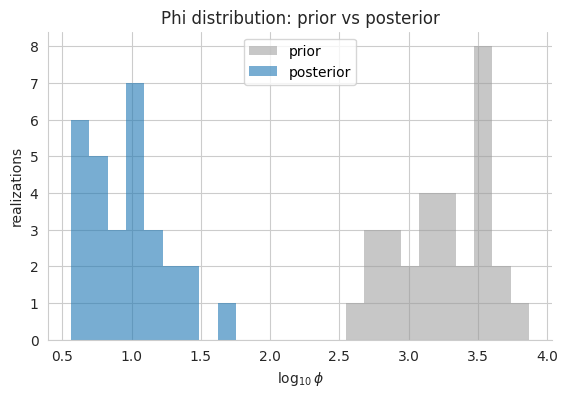

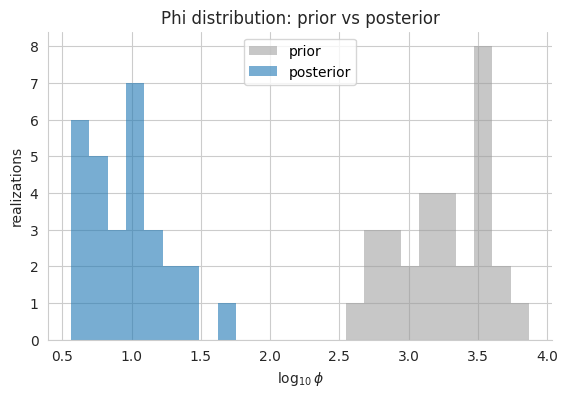

In [6]:
if ies is not None:
    display(ies.plot_phi())
    display(ies.plot_phi_distribution())
    display(ies.plot_phi_distribution(backend='matplotlib'))

## 6. Phi contribution by group, and parameters at bounds

`plot_phi_contributions` breaks total phi down by observation group (is one group dominating the misfit?); `parameters_at_bounds` reports the fraction of each parameter group pinned at a bound (are bounds too tight?). **What to look for:** a balanced phi across groups, and few parameters stuck at bounds.

In [7]:
if ies is not None:
    display(ies.plot_phi_contributions())
    display(ies.parameters_at_bounds())
    display(ies.plot_parameters_at_bounds())

,n_parameters,n_at_lower,n_at_upper,pct_at_bound
pargp,,,,
kl1,2500,0,0,0.0
kl2,2500,0,0,0.0
recharge,1,0,0,0.0


## 7. Forecast uncertainty -- "uncertainty analysis for free"

The posterior distribution of the prediction of interest (a down-valley head near the lake). **What to look for:** history matching should *narrow* the forecast relative to the prior -- but a good fit is not a good prediction, so value the posterior spread.

In [8]:
if ies is not None:
    display(ies.forecasts())
    name = ies.forecast_names[0]
    display(ies.forecast(name).plot())

,prior_mean,prior_std,prior_p05,prior_p50,prior_p95,posterior_mean,posterior_std,posterior_p05,posterior_p50,posterior_p95,truth,uncertainty_reduction
forecast,,,,,,,,,,,,
oname:fore1_otype:lst_usecol:fore_lakehead_per:0,103.535504,3.251804,100.304698,103.062927,109.131341,109.103587,0.347358,108.525332,109.045844,109.612240,108.526230,0.893180
oname:fore1_otype:lst_usecol:fore_lakehead_per:1,104.161938,3.178898,100.996460,103.743776,109.608925,109.644873,0.336067,109.079933,109.588603,110.137995,109.059245,0.894282
oname:fore1_otype:lst_usecol:fore_lakehead_per:2,104.515252,3.059555,101.415525,104.149292,109.693424,109.745457,0.322900,109.207267,109.701230,110.221978,109.155344,0.894462
oname:fore1_otype:lst_usecol:fore_lakehead_per:3,104.595025,2.977499,101.496364,104.208211,109.625833,109.713809,0.319895,109.184585,109.681301,110.184773,109.129935,0.892563
oname:fore1_otype:lst_usecol:fore_lakehead_per:4,104.544105,2.952000,101.389770,104.109247,109.544009,109.679785,0.322672,109.150302,109.648543,110.156956,109.110957,0.890694
oname:fore1_otype:lst_usecol:fore_lakehead_per:5,104.413749,2.959845,101.216153,103.952972,109.440468,109.606107,0.328512,109.061274,109.574583,110.091832,109.056083,0.889011


## 8. Property patterns -- did IES recover the K field?

*"Property patterns: plausible or laughable?"* Because we declared `capture=True`, every realization's resolved K field is recorded, so we can map it. Compare the known **truth** K against the **posterior mean** (what IES recovered) and the **posterior std** (where K is still uncertain).

**What to look for:** with only head observations, fine K structure *cannot* be fully resolved -- the posterior mean is a smooth, plausible field that adjusts K **near the observation wells** and stays close to the prior elsewhere. The std map shows exactly where the data does (and does not) constrain K. A posterior that reproduced the sharp truth everywhere from sparse heads would be *too good to be true*.

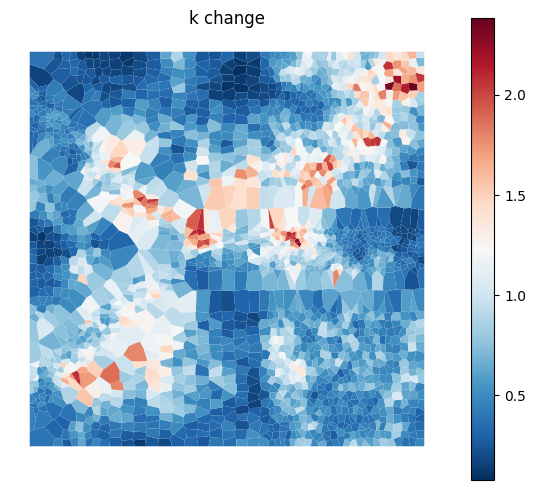

,cell,prior_mean,prior_std,posterior_mean,posterior_std,base,change
0,0,36.387487,56.399561,16.386146,8.199899,12.606856,0.450324
1,1,35.513879,57.027138,14.798133,7.246115,13.289498,0.416686
2,2,29.439938,33.235916,11.516459,7.177049,12.212796,0.391185
3,3,30.209208,35.397455,13.229310,6.635288,13.774183,0.437923
4,4,29.126761,33.997301,7.644718,3.807430,7.703990,0.262464


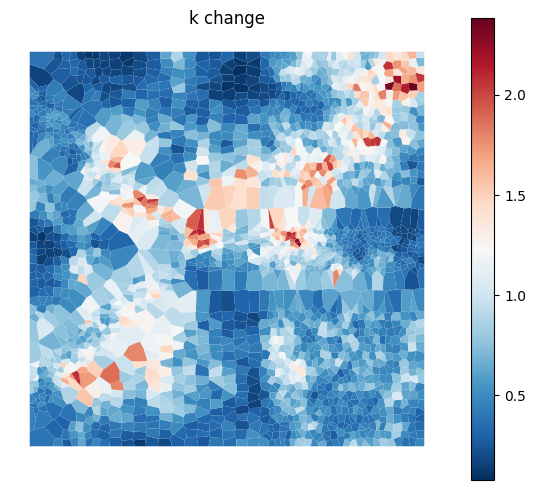

In [9]:
if ies is not None:
    layer = 0
    truth_k = list(demo.truth_k[layer])                       # known truth (layer 1)
    display(build_choropleth(demo.model.vor, custom_zs=truth_k, layer=layer))
    display(ies.plot_field('k', stat='mean', which='posterior', layer=layer))   # recovered
    display(ies.plot_field('k', stat='std', layer=layer))                       # uncertainty
    display(ies.plot_field('k', stat='change', layer=layer, backend='matplotlib'))  # prior->post
    display(ies.field('k', layer=layer).head())

## 9. The single best realization, and the report bundle

Carry the **base** (minimum-error-variance) realization forward, never the lowest-phi one. `report(...)` bundles the diagnostics into one HTML file.

In [10]:
if ies is not None:
    print('recommended realization:', ies.best())
    report_path = ies.report(artifact_root / 'uncertainty_review.html')
    print('wrote', report_path)

recommended realization: base


wrote ..\artifacts\canonical_pest\uncertainty_review.html


## Interpretation checklist (run this every cycle)

- **Prior Monte Carlo first:** is the prior wide enough, and is any observation in conflict with it?
- **Phi:** did it drop, and is the posterior phi near (not far below) the observation count?
- **Phi by group / parameters at bounds:** is one group dominating, or are bounds too tight?
- **Forecast:** value the posterior *spread* -- a good fit is not a good prediction.
- **Property patterns:** are the posterior K maps geologically plausible? Trust them only where the data constrains them (low posterior std).
- Carry the **base** realization forward.

## Your PEST runs live with the model

Because the calibration workspace defaults to `<model workspace>/pest/<name>`,
every PEST run done on this model is discoverable straight from the model via
`model.pest_runs` (or `run.pest_runs` for a loaded run) -- no need to remember
where the master directories were written. Reopen any of them for the full
`IesResults` review **without re-running**.

In [ ]:
# Discover every PEST run done on this model, and reopen one for review.
runs = demo.model.pest_runs
for run in runs:
    print(run)

this_run = next((r for r in runs if r.name == cal.name and r.kinds), None)
if this_run is not None:
    review = this_run.review()          # -> IesResults (identical to a fresh run_ies)
    display(review.plot_phi())
else:
    print('No completed PEST runs yet -- set RUN_IES = True above and re-run.')